# **Customer Churn Prediction (Telecom Sector)**

**Step 1: Import Required Libraries**


In [ ]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report

import joblib

**Step 2: Load the Dataset**

In [ ]:
data = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")
data.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


**Step 3: Explore the Dataset**

In [ ]:
print(data.columns)
print(data.dtypes)
print(data.isnull().sum())

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup',
       'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')
customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object
customerID          0
gender          

**Step 4: Data Cleaning and Preprocessing**

In [ ]:
# Remove customerID (not useful for prediction)
data = data.drop("customerID", axis=1)

# Convert TotalCharges to numeric
data["TotalCharges"] = pd.to_numeric(data["TotalCharges"], errors="coerce")

# Handle missing values
data["TotalCharges"].fillna(data["TotalCharges"].median(), inplace=True)

In [ ]:
data["Churn"] = data["Churn"].map({"Yes": 1, "No": 0})

print(data["Churn"].value_counts())

Churn
0    5174
1    1869
Name: count, dtype: int64


**Step 5: Exploratory Data Analysis (EDA)**

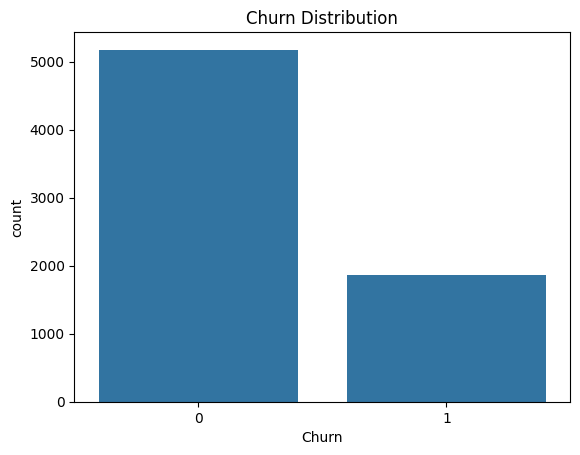

In [ ]:
sns.countplot(x="Churn", data=data)
plt.title("Churn Distribution")
plt.show()

**Step 6: Feature Engineering**

In [ ]:
# Monthly value ratio
data["ValueRatio"] = data["TotalCharges"] / (data["tenure"] + 1)

# Tenure group
data["TenureGroup"] = pd.cut(
    data["tenure"],
    bins=[0,12,24,48,72],
    labels=["New","Short","Medium","Long"]
)

**Step 7: Split Features and Target Variable and**

**Step 8: Split Training and Testing Data**

In [ ]:
X = data.drop("Churn", axis=1)
y = data["Churn"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

**Step 9: Data Preprocessing Pipeline**

In [ ]:
numeric_features = X.select_dtypes(include=["int64","float64"]).columns
categorical_features = X.select_dtypes(include=["object","category"]).columns

numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer([
    ("num", numeric_pipeline, numeric_features),
    ("cat", categorical_pipeline, categorical_features)
])

**Step 10: Train Logistic Regression Model**

In [ ]:
log_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(max_iter=1000))
])

log_model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  Index(['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges', 'ValueRatio'], dtype='object')),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  Index(['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV',
       'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'TenureGroup'],
      dtype='object'))])),
                ('model', LogisticRegression(max_iter=1000))])

In [ ]:
pred = log_model.predict(X_test)
prob = log_model.predict_proba(X_test)[:,1]

print("Accuracy:", accuracy_score(y_test, pred))
print("Precision:", precision_score(y_test, pred))
print("Recall:", recall_score(y_test, pred))
print("F1:", f1_score(y_test, pred))
print("ROC AUC:", roc_auc_score(y_test, prob))

print(confusion_matrix(y_test, pred))
print(classification_report(y_test, pred))

Accuracy: 0.8034066713981547
Precision: 0.6644067796610169
Recall: 0.5240641711229946
F1: 0.585949177877429
ROC AUC: 0.8465085638998683
[[936  99]
 [178 196]]
              precision    recall  f1-score   support

           0       0.84      0.90      0.87      1035
           1       0.66      0.52      0.59       374

    accuracy                           0.80      1409
   macro avg       0.75      0.71      0.73      1409
weighted avg       0.79      0.80      0.80      1409



**Step 11: Train and Evaluate Random Forest Model**

In [ ]:
rf_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestClassifier(n_estimators=200, random_state=42))
])

rf_model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  Index(['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges', 'ValueRatio'], dtype='object')),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotE...wn='ignore'))]),
                                                  Index(['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV',
       'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'TenureGroup'],
      dtype='object'))])),
                ('model',
                 RandomForestClassifier(n_estimators=200, random_state=42))])

In [ ]:
rf_pred = rf_model.predict(X_test)
rf_prob = rf_model.predict_proba(X_test)[:,1]

print("Accuracy:", accuracy_score(y_test, rf_pred))
print("ROC AUC:", roc_auc_score(y_test, rf_prob))

Accuracy: 0.7764371894960965
ROC AUC: 0.8210002841716398


**Step 12: Cross Validation**

In [ ]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scores = cross_val_score(rf_model, X, y, cv=cv, scoring="roc_auc")

print("CV Scores:", scores)
print("Mean:", scores.mean())

CV Scores: [0.83647472 0.8216513  0.83806867 0.80934452 0.82185764]
Mean: 0.8254793698313001


**Step 13: Hyperparameter Tuning**

In [ ]:
param_grid = {
    "model__n_estimators": [100,200],
    "model__max_depth": [None,10]
}

grid = GridSearchCV(rf_model, param_grid, cv=3, scoring="roc_auc")
grid.fit(X_train, y_train)

print(grid.best_params_)

{'model__max_depth': 10, 'model__n_estimators': 200}


**Step 14: Save the Trained Model**

In [ ]:
joblib.dump(grid.best_estimator_, "churn_model.joblib")

['churn_model.joblib']

**Step 15: Predict New Customer Churn**

In [ ]:
new_customer = X_test.iloc[:2]

prediction = grid.best_estimator_.predict(new_customer)
probability = grid.best_estimator_.predict_proba(new_customer)[:,1]

print(prediction)
print(probability)

[0 1]
[0.01268347 0.76043105]
